# Выбросы

Содержание:
1. Импорты библиотек
2. Описание данных
3. Z-score и измененный z-score
4. Квартильный размах
5. Модели


### 1. Импорты библиотек

In [ ]:
import pandas as pd
import numpy as np
import nbformat
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import statistics
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.ensemble import IsolationForest
from IPython.display import Image

#### Настройки вывода

In [2]:
# Показать все колонки
pd.set_option('display.max_columns', None)
# Установить ширину отображения
pd.set_option('display.width', None)
# Отобразить все колонки без сокращения
pd.set_option('display.expand_frame_repr', False)

### 2. Описание данных

In [63]:
# Исходный датафрейм
df = pd.read_csv('imdb_top_1000.csv')

In [64]:
df.head(1)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"


Датасет с топ-1000 фильмов imdb

Параметры:
1) Poster_Link - ссылка на постер
2) Series_Title - название
3) Released_Year - год выхода
4) Certificate - возрастной рейтинг
5) Runtime - длительность
6) Genre - жанр
7) IMDB_Rating - рейтинг IMDB
8) Overview - описание
9) Meta_score - оценка Meta_score
10) Director - режиссер
11) Star1 - актер 1
12) Star2 - актер 2
13) Star3 - актер 3
14) Star4 - актер 4
15) No_of_Votes - число голосов
16) Gross - доход


In [66]:
df.info() ## получаем типы данных и число пропусков в колонках
df = df.fillna(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    1000 non-null   object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [20]:
## Оставляю для примера только количественные показатели
df = df[['IMDB_Rating','Meta_score','No_of_Votes']]
df

,IMDB_Rating,Meta_score,No_of_Votes
0,9.3,80.0,2343110
1,9.2,100.0,1620367
2,9.0,84.0,2303232
3,9.0,90.0,1129952
4,9.0,96.0,689845
...,...,...,...
995,7.6,76.0,166544
996,7.6,84.0,34075
997,7.6,85.0,43374
998,7.6,78.0,26471


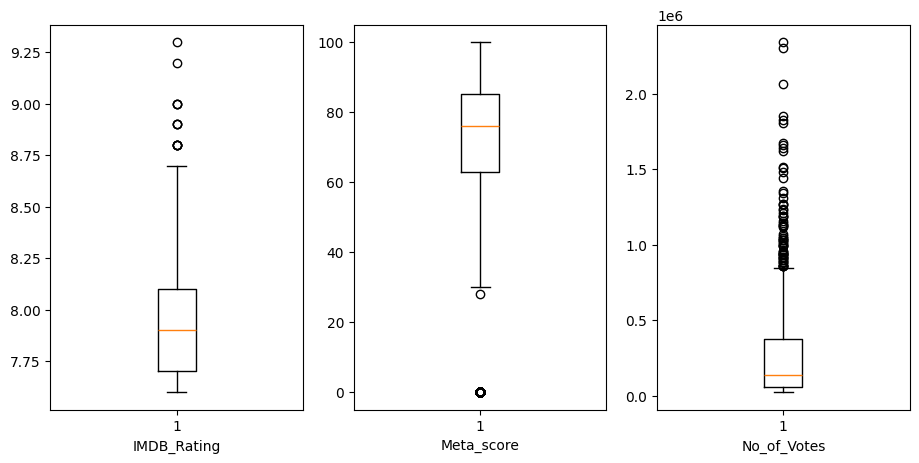

In [22]:
### Показываем все показатели на боксплотах

matplotlib.rcParams['figure.figsize'] = (15, 5)
for i,j in enumerate(df.columns):
    plt.subplot(1, 4, i+1) # (rows, columns, panel number)
    plt.boxplot(df[j])
    plt.xlabel(j)

## Видим выбросы


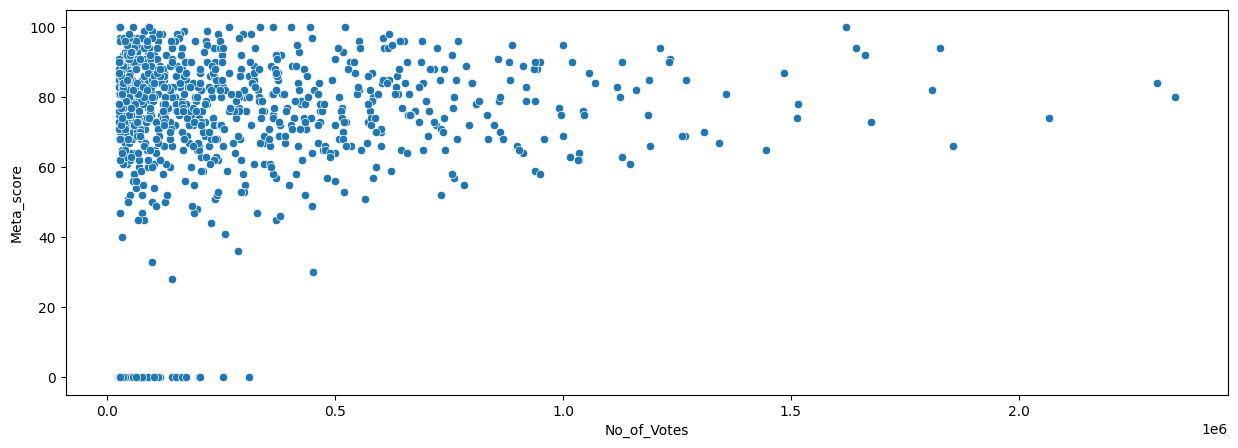

In [23]:
## Так тоже видно выбросы - но тут еще заполненные пропуски видно
sns.scatterplot(x = df.No_of_Votes, y = df.Meta_score);

### 3. Z-score и измененный z-score

In [21]:
## Количественно выбросы можно найти через стандартизированную оценку (z-оценку, z-score).

z = df.apply(stats.zscore)
z.head() ## на сколько средних квадратических отклонений каждое значение отличается от среднего

,IMDB_Rating,Meta_score,No_of_Votes
0,4.905332,0.467028,6.324451
1,4.542162,1.121587,4.115639
2,3.815823,0.597940,6.202578
3,3.815823,0.794307,2.616857
4,3.815823,0.990675,1.271824


In [22]:
## Больше чем на три стандартных отклонений отличается - подозрение на выброс
df[(np.abs(z) > 3).any(axis = 1)].head()

,IMDB_Rating,Meta_score,No_of_Votes
0,9.3,80.0,2343110
1,9.2,100.0,1620367
2,9.0,84.0,2303232
3,9.0,90.0,1129952
4,9.0,96.0,689845


In [23]:
## По маске для столбца

# выведем True там, где в столбце RM значение меньше трех СКО
col_mask = np.where(np.abs(z.No_of_Votes) < 3, True, False)
 
# применим маску к столбцу
df.No_of_Votes[col_mask].head()

3     1129952
4      689845
7     1213505
12     688390
15    1020727
Name: No_of_Votes, dtype: int64

In [24]:
## Удалим выбросы для всего датафрейма
z_mask = (np.abs(z) < 3).all(axis = 1)
 
df_z = df[z_mask]
df_z.shape

(976, 3)

In [ ]:
## Измененный z-score
## В обычной измененной оценке мы используем СКО, но оно считается по данным с выбросами
## Можно использовать измененную оценку - Модифицированная z-оценка (\[M_{i}\]) вычисляется через медиану и медианное абсолютное отклонение (MAD)
## где MAD представляет собой среднее абсолютное отклонение (median absolute deviation) 
## 0.6745 — коэффициент согласования с нормальным распределением (вероятность для 75-го процентиля)

In [47]:
# рассчитаем MAD
median = df.median()
dev_median = df - (df.median())
abs_dev_median = np.abs(dev_median)
MAD = abs_dev_median.median()
 
# рассчитаем измененный z-score
# добавим константу, чтобы избежать деления на ноль
zmod = (0.6745 * (df - df.median())) / (MAD + 1e-5)
 
# создадим фильтр
zmod_mask = (np.abs(zmod) < 3.5).all(axis = 1)
 
# выведем результат для того же столбца
df_zmod = df[zmod_mask]


In [52]:
print(len(df.No_of_Votes[col_mask]))
len(df_zmod.No_of_Votes[zmod_mask])
## Значительно изменилось число удаленных элементов

980


727

In [53]:
## Корреляция между показателями уменьшилась
print(df[['No_of_Votes', 'IMDB_Rating']].corr())
print(df_z[['No_of_Votes', 'IMDB_Rating']].corr())
print(df_zmod[['No_of_Votes', 'IMDB_Rating']].corr())

             No_of_Votes  IMDB_Rating
No_of_Votes     1.000000     0.494979
IMDB_Rating     0.494979     1.000000
             No_of_Votes  IMDB_Rating
No_of_Votes     1.000000     0.325118
IMDB_Rating     0.325118     1.000000
             No_of_Votes  IMDB_Rating
No_of_Votes     1.000000     0.157629
IMDB_Rating     0.157629     1.000000


### 4. Квартильный размах


In [54]:
### Исходим из логики нормального распределения 
q1 = -0.6745
q3 = 0.6745
 
iqr = q3 - q1
 
lower_bound = q1 - (1.5 * iqr) 
upper_bound = q3 + (1.5 * iqr)
 
# тогда lower_bound и upper_bound почти равны трем СКО от среднего
# (было бы точнее, если использовать 1.75)
print(lower_bound, upper_bound)

-2.698 2.698


In [60]:

# найдем границы 1.5 * IQR по каждому столбцу
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
 
# создадим маску для выбросов 
# если хотя бы один выброс в строке (True), метод .any() сделает всю строку True
mask_out = ((df < lower) | (df > upper)).any(axis = 1)

# найдем выбросы во всем датафрейме
df[mask_out].shape

# возьмем датафрейм без выбросов
df_iqr = df[~mask_out]

In [61]:
df_iqr[['No_of_Votes', 'IMDB_Rating']].corr()

,No_of_Votes,IMDB_Rating
No_of_Votes,1.000000,0.272047
IMDB_Rating,0.272047,1.000000


### 5. Модели

<Axes: xlabel='No_of_Votes', ylabel='Meta_score'>

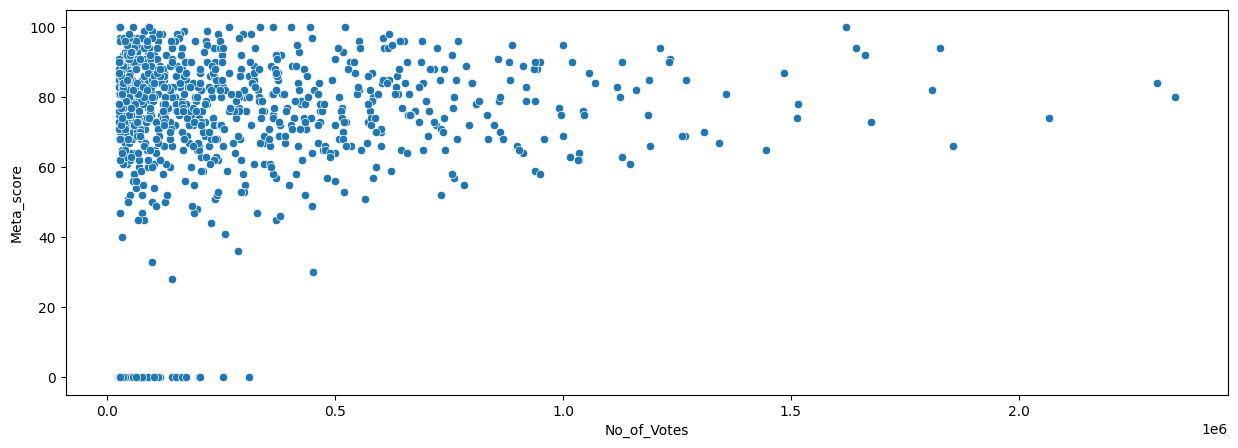

In [67]:
sns.scatterplot(x = df.No_of_Votes, y = df.Meta_score)

In [ ]:
X = df[['No_of_Votes','Meta_score']] 


In [69]:
clf = IsolationForest(max_samples = 100, random_state = 0)
clf.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",100
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",0
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [70]:
labels = clf.predict(X)      # 1 = норма, -1 = выброс

outliers = X[labels == -1]
inliers  = X[labels == 1]
print(f"Выбросов: {(labels == -1).sum()} из {len(X)}")

Выбросов: 367 из 1000


In [71]:
scores = clf.decision_function(X)   # < 0 → выброс, чем меньше, тем аномальнее
# clf.score_samples(X) — «сырой» скор, без сдвига на порог

df_clf = X.copy()                       # если X — DataFrame
df_clf['score'] = scores
df_clf['is_outlier'] = labels == -1
df_clf.sort_values('score').head(10) 

,No_of_Votes,Meta_score,score,is_outlier
1,1620367,100.0,-0.241323,True
6,1826188,94.0,-0.231986,True
2,2303232,84.0,-0.231236,True
5,1642758,94.0,-0.225344,True
0,2343110,80.0,-0.224110,True
10,1661481,92.0,-0.222345,True
8,2067042,74.0,-0.221418,True
9,1854740,66.0,-0.219877,True
14,1676426,73.0,-0.208239,True
11,1809221,82.0,-0.198868,True


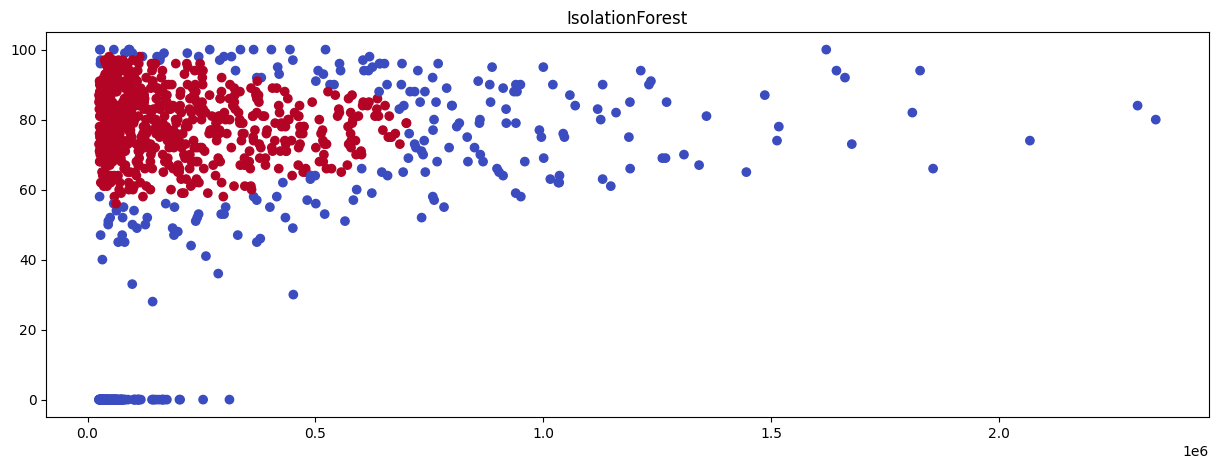

In [73]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='coolwarm')
plt.title('IsolationForest')
plt.show()